In [1]:
#Import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
# Load BIRDBASE data
birdbase = pd.read_excel('~/DSP_group_project_avian_datasets/data/raw/Birdbase_data/BIRDBASE v2025.1 Sekercioglu et al. Final.xlsx', skiprows=1, sheet_name=None)

birdbase_data = birdbase['Data']
birdbase_nest = pd.read_excel('~/DSP_group_project_avian_datasets/data/raw/Birdbase_data/BIRDBASE v2025.1 Sekercioglu et al. Final.xlsx', sheet_name="Nest Details")
#birdbase_nest = birdbase['Nest Details']

# Load abundance data
abundance = pd.read_excel('~/DSP_group_project_avian_datasets/data/raw/abundance_data/pnas.2023170118.sd01.xlsx', sheet_name='all_species_summary_table')

# Load Avonet data
avonet = pd.read_excel('~/DSP_group_project_avian_datasets/data/raw/Avonet_data/ELEData/TraitData/AVONET1_Birdlife.xlsx', sheet_name='AVONET1_BirdLife')
avonet2 = pd.read_excel('~/DSP_group_project_avian_datasets/data/raw/Avonet_data/ELEData/TraitData/AVONET2_eBird.xlsx', sheet_name='AVONET2_eBird')
avonet3 = pd.read_excel('~/DSP_group_project_avian_datasets/data/raw/Avonet_data/ELEData/TraitData/AVONET3_BirdTree.xlsx', sheet_name='AVONET3_BirdTree')


# Load eye measurements data
eye = pd.read_csv('~/DSP_group_project_avian_datasets/data/raw/eye_anatomical_measurements/Ritland_eyes_raw_FINAL.csv')

# Load colour dataset
colours = pd.read_csv('~/DSP_group_project_avian_datasets/data/raw/colour/Data_S1/Information_for_Illustrations_and_proportion_of_24_colors.csv')

In [3]:
# Ignoring the eye database becuase of it's incompleteness and repeat info
#avonet2.columns

In [4]:
# Name all the cols scientific name as scientific_name to make it wasier to work with
birdbase_data.rename(columns={'Latin (BirdLife > IOC > Clements>AviList)': 'scientific_name'}, inplace=True)
avonet.rename(columns={'Species1': 'scientific_name'}, inplace=True)
abundance.rename(columns={'Scientific name': 'scientific_name'}, inplace=True)
birdbase_nest.rename(columns={'Latin.Name': 'scientific_name'}, inplace=True)
colours.rename(columns = {'Sci_name': 'scientific_name'}, inplace=True)
avonet2.rename(columns={'Species2': 'scientific_name'}, inplace=True)
avonet3.rename(columns={'Species3': 'scientific_name'}, inplace=True)

In [5]:
# Just checking which databases have repeats
print(birdbase_data['scientific_name'].value_counts()[lambda x: x > 1])
print(avonet['scientific_name'].value_counts()[lambda x: x > 1])
print(avonet2['scientific_name'].value_counts()[lambda x: x > 1])
print(avonet3['scientific_name'].value_counts()[lambda x: x > 1])
print(abundance['scientific_name'].value_counts()[lambda x: x > 1])
#print(eye['species_jetz'].value_counts()[lambda x: x > 1])
print(birdbase_nest['scientific_name'].value_counts()[lambda x: x > 1])
#print(colours['scientific_name'].value_counts()[lambda x: x>1])

Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


In [6]:
# clean all col names so that it is easier to work with by removing the empty spaces leading and trailing the col name
for df in [birdbase_data, birdbase_nest, colours, avonet, abundance, avonet2, avonet3]:
    df.columns = df.columns.str.strip()


In [7]:
# standerdises the names to all small for scientific name in all datsets
def clean_name(col):
    return (col
            .str.lower()
            .str.strip()
            .str.replace(r'\s+', ' ', regex=True))

for df in [birdbase_data, birdbase_nest, avonet, abundance, colours, avonet2, avonet3]:
    df['scientific_name'] = clean_name(df['scientific_name'])

birdbase_data['HBW/BirdLife International (v9.1)'] = clean_name(birdbase_data['HBW/BirdLife International (v9.1)'])
birdbase_data['eBird/Clements (V2024b)']= clean_name(birdbase_data['eBird/Clements (V2024b)'])
birdbase_data['AviList v1 2025'] = clean_name(birdbase_data['AviList v1 2025'])
birdbase_data['IOC World Bird List (v15.1)'] = clean_name(birdbase_data['IOC World Bird List (v15.1)'])

In [8]:
# enumerates missing 
for i, df in enumerate([birdbase_data, birdbase_nest, avonet, abundance, avonet2, avonet3], 1):
    print(f"df{i} missing names:", df['scientific_name'].isna().sum())

df1 missing names: 0
df2 missing names: 0
df3 missing names: 0
df4 missing names: 0
df5 missing names: 0
df6 missing names: 0


In [9]:
# enumerates total missing values 
for i, df in enumerate([birdbase_data, birdbase_nest, avonet, abundance, avonet2, avonet3, colours], 1):
    print(f"df {i} no. of unique names:", df['scientific_name'].nunique(dropna=False))

# Using avonet birdlife taxonmomy gives the most matches despite 319 unmatched so we will go with that

df 1 no. of unique names: 11589
df 2 no. of unique names: 11589
df 3 no. of unique names: 11009
df 4 no. of unique names: 9700
df 5 no. of unique names: 10661
df 6 no. of unique names: 9993
df 7 no. of unique names: 10290


In [10]:
len(set(birdbase_data['scientific_name']) & set(colours['scientific_name']))
#len(set(birdbase_data['scientific_name']) & set(abundance['scientific_name']))

9537

In [165]:
10290 - 9537

753

In [11]:
set1 = set(birdbase_data['scientific_name'])
set3 = set(avonet['scientific_name'])

unmatched_df1 = avonet[~avonet['scientific_name'].isin(set1)]
missing_from_birdbase = set3 - set1
len(unmatched_df1)
unmatched_df1.head()

,Sequence,scientific_name,Family1,Order1,Avibase.ID1,Total.individuals,Female,Male,Unknown,Complete.measures,...,Habitat.Density,Migration,Trophic.Level,Trophic.Niche,Primary.Lifestyle,Min.Latitude,Max.Latitude,Centroid.Latitude,Centroid.Longitude,Range.Size
619,1061.0,caprimulgus centralasicus,Caprimulgidae,Caprimulgiformes,AVIBASE-0BC7890E,1,1,0,0,1,...,2,NaN,Carnivore,Invertivore,Aerial,NaN,NaN,NaN,NaN,NaN
734,1480.0,amazilia amabilis,Trochilidae,Caprimulgiformes,AVIBASE-98B261C6,22,3,14,5,6,...,2,1.0,Herbivore,Nectarivore,Aerial,-3.98,14.18,6.51,-78.67,298612.12
735,1472.0,amazilia amazilia,Trochilidae,Caprimulgiformes,AVIBASE-62AFA922,5,2,3,0,4,...,2,1.0,Herbivore,Nectarivore,Aerial,-15.53,1.08,-6.41,-79.11,169380.82
736,1493.0,amazilia bartletti,Trochilidae,Caprimulgiformes,AVIBASE-DC2C4D3F,13,2,11,0,3,...,2,1.0,Herbivore,Nectarivore,Aerial,-15.53,-5.41,-11.00,-69.00,1032986.12
737,1483.0,amazilia beryllina,Trochilidae,Caprimulgiformes,AVIBASE-EDCAC4EA,5,2,3,0,4,...,2,1.0,Herbivore,Nectarivore,Aerial,13.25,30.75,19.81,-99.94,607143.11


In [12]:
set1 = set(birdbase_data['scientific_name'])
set4 = set(abundance['scientific_name'])

abundance_missing_from_birdbase = abundance[~abundance['scientific_name'].isin(set1)]
len(abundance_missing_from_birdbase)

abundance_missing_from_birdbase.head()


,Common name,scientific_name,Order,Family,95% Lower CI,Abundance estimate,95% Upper CI,Range adjusted,Training species
40,Tennessee Warbler,oreothlypis peregrina,Passeriformes,Parulidae (New World Warblers),8020862,169906051,3224633644,True,True
46,Brown Skua,stercorarius antarcticus,Charadriiformes,Stercorariidae (Skuas and Jaegers),1936281,157734474,16126172081,True,False
49,Ruby-crowned Kinglet,regulus calendula,Passeriformes,Regulidae (Kinglets),13301937,131624404,1221623098,True,True
58,Franklin's Gull,leucophaeus pipixcan,Charadriiformes,"Laridae (Gulls, Terns, and Skimmers)",1135134,108014410,8636740617,True,False
65,Wedge-rumped Storm-Petrel,oceanodroma tethys,Procellariiformes,Hydrobatidae (Northern Storm-Petrels),1129366,95696643,7760594171,False,False


In [13]:
# I will define a base set using the birdbase ID since it is the most comprehensive and recent
bird_set = set(birdbase_data['scientific_name'])

avonet_matched = avonet[avonet['scientific_name'].isin(bird_set)]
avonet_unmatched = avonet[~avonet['scientific_name'].isin(bird_set)]

abundance_matched = abundance[abundance['scientific_name'].isin(bird_set)]
abundance_unmatched = abundance[~abundance['scientific_name'].isin(bird_set)]

colours_matched = colours[colours['scientific_name'].isin(bird_set)]
colours_unmatched = colours[~colours['scientific_name'].isin(bird_set)]

print(len(avonet_matched), len(avonet_unmatched))
print(len(abundance_matched), len(abundance_unmatched))
# ok cool number match

avonet_unmatched.to_csv("~/DSP_group_project_avian_datasets/data/processed/avonet_unmatched.csv", index=False)
abundance_unmatched.to_csv("~/DSP_group_project_avian_datasets/data/processed/abundance_unmatched.csv", index=False)
colours_unmatched.to_csv("~/DSP_group_project_avian_datasets/data/processed/colours_unmatched.csv", index=False)
colours_matched.to_csv("~/DSP_group_project_avian_datasets/data/processed/colours_matched.csv", index=False)

10690 319
8948 752


In [95]:
birdbase_data.columns

Index(['IOC 15.1', 'English Name (BirdLife > IOC > Clements>AviList)',
       'scientific_name', 'HBW/BirdLife International (v9.1)',
       'IOC World Bird List (v15.1)', 'eBird/Clements (V2024b)',
       'AviList v1 2025', 'Order', 'Family IOC 15.1', 'Family Clements v2024b',
       'Family HBW/BirdLife v9.1 (2024)', 'Family AviList v1 2025', 'Genus',
       'Species', 'Source', '2024 IUCN Red List category', 'RR', 'ISL', 'RLM',
       'LAT', 'Female MinMass', 'Female MaxMass', 'Male MinMass',
       'Male MaxMass', 'Unsexed MinMass', 'Unsexed MaxMass', 'Average Mass',
       'Xmin', 'NormMin', 'Elevational Range', 'NormMax', 'Xmax', 'F', 'BM',
       'WD', 'SH', 'SV', 'G', 'PL', 'R', 'D', 'A', 'RV', 'C', 'W', 'SE', 'O',
       'O- DESC', 'Primary Habitat', 'HB', 'Primary Diet', 'IN-Wt', 'FR-Wt',
       'NE-Wt', 'SE-Wt', 'VE-Wt', 'FI-Wt', 'SC-Wt', 'PL-Wt', 'MS-Wt', 'SUM-Wt',
       'Desc', 'DB', 'Diet_Lit', 'ESI', 'Social_1', 'Social_2', 'Social_3',
       'Social_4', 'Social_5', 'So

In [ ]:
# Let's merge!
'''
merged = birdbase_data.merge(
    birdbase_nest,
    on='scientific_name',
    how='left'
)
'''

merged = (birdbase_data
    .merge(avonet_matched, on='scientific_name', how='left')
    .merge(abundance_matched, on='scientific_name', how='left')
)

#merged.to_csv("~/DSP_group_project_avian_datasets/data/processed/merged_raw.csv", index=False)

In [39]:
#print(len(merged.columns))
#print(len(birdbase_data.columns) + len(birdbase_nest.columns))
#for col in merged.columns:
  #  print(col)

In [23]:
merged = merged.drop(columns=['IOC 15.1', 'Source', 'HBW/BirdLife International (v9.1)', 'IOC World Bird List (v15.1)', 'eBird/Clements (V2024b)', 'AviList v1 2025', 
                              'Order_y', 'Family Clements v2024b', 'Family HBW/BirdLife v9.1 (2024)', 'Family AviList v1 2025', 'Xmin', 'Xmax', 'O- DESC', 'Desc', 'Diet_Lit',
                              'Sequence', 'Family1', 'Order1' ,'Avibase.ID1','Total.individuals', 'Female', 'Male', 'Unknown', 'Complete.measures', 'Mass.Source', 'Mass.Refs.Other',
                              'Inference', 'Traits.inferred', 'Reference.species', 'Common name','Order_y', 'Family','Training species', 'Range adjusted'  ])

In [28]:
print(len(merged.columns))
merged.to_csv("~/DSP_group_project_avian_datasets/data/processed/merged.csv", index=False)

108


In [26]:
coverage = pd.DataFrame({
    'non_null_count': merged.notna().sum(),
    'null_count': merged.isna().sum(),
    'coverage_percent': merged.notna().mean() * 100
}).sort_values(by='coverage_percent', ascending=False)

#coverage.tail(20)
pd.set_option('display.max_rows', None)
#coverage

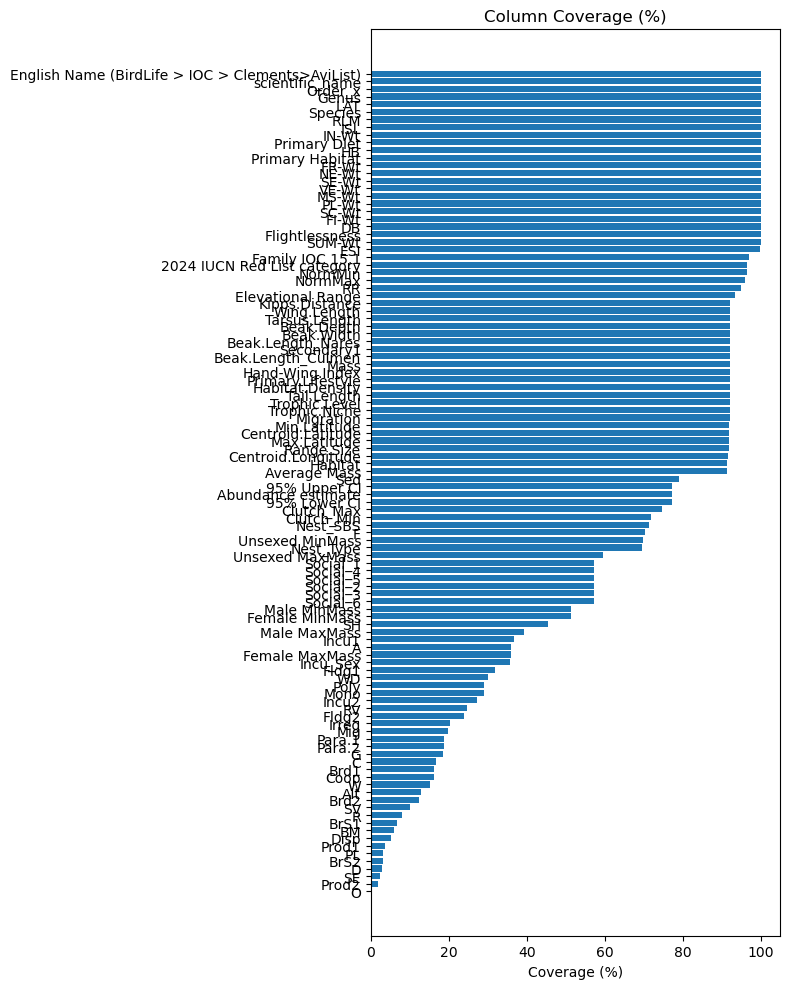

In [35]:
# plot for data covergae
plt.figure(figsize=(8, 10))

plt.barh(coverage.index, coverage['coverage_percent'])

plt.xlabel('Coverage (%)')
plt.title('Column Coverage (%)')

plt.gca().invert_yaxis()  

plt.tight_layout()
plt.savefig("/home/anagha/DSP_group_project_avian_datasets/results/coverage.png", dpi=300)
plt.show()

In [37]:
# A text file with all the birds being considered
merged['scientific_name'].dropna().drop_duplicates().to_csv(
    "/home/anagha/DSP_group_project_avian_datasets/data/processed/bird_list.txt", index=False, header=False
)